In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [6]:
from docplex.mp.model import Model

In [7]:
demand_data = pd.read_csv('data/ed/demand.csv')
fuels_data = pd.read_csv('data/ed/fuels_data.csv')
generators_data = pd.read_csv('data/ed/generators_data.csv')
variability_data = pd.read_csv('data/ed/generators_variability.csv')

In [27]:
print(fuels_data.head())

                        Fuel  Cost_per_MMBtu  CO2_content_tons_per_MMBtu
0                        NaN            0.00                     0.00000
1         pacific_naturalgas            2.57                     0.05306
2   pacific_naturalgas_ccs90            3.04                     0.00531
3  pacific_naturalgas_ccs100            3.10                     0.00000


### Economic Dispatch

A basic economic dispatch optimization might seek to simply identify the cheaptest combination of generation to satisfy load at the system level (ignoring the transmision network topology). This is the same idea as a power supply stack model. We might model this process via the following optimization. 

$$ 

min \sum_{g \in G} c_g \times p_g = min \sum_{g \in G} \text{VariableCost}_g \times p_g = min \sum_{g \in G} (\text{OperationsCost}_g + (\text{HeatRate}_g) \times \text{FuelCost}) \times p_g

$$

subject to the following constraints
$$

\sum_{g \in G} p_g = D, \newline p_g \geq P_{min}, \newline p_g \leq P_{max}

$$

Note that this simplifed model does not yet take into account transmission network related constraints. This optimization has the effect of dispatching generators according to their merit order, and the system energy price is the marginal cost of serving an additional unit of demand. In other words, the calculated system-wide price of energy is the marginal cost to supply one additional unit of demand in the system, $\frac{\partial \text{Price}}{\partial D}$. We can implement this optimization using the CPLEX API in Python. In reality, CPLEX isn't even necessary, as we can sort in numpy and take a cumulative sum till demand is satisfied. The optimization framework is helpful to see conceptually and extend to the more advanced optimization frameworks that follow. 

In [10]:
## simple CPLEX implementation of economic dispatch

fuel_by_generator = (
    generators_data.
    loc[(generators_data['num_units'] > 0)]
    .merge(fuels_data, on='Fuel', how='left')
    .set_index('R_ID')
) 

demand_values = demand_data["Demand"].astype(float)
G = list(fuel_by_generator.index)

## array of variable costs by WECC generator 
var_cost = fuel_by_generator['Var_OM_cost_per_MWh'].to_dict()
heat_rate = fuel_by_generator['Heat_rate_MMBTU_per_MWh'].to_dict()
fuel_cost = fuel_by_generator['Cost_per_MMBtu'].to_dict()
gen_limits = fuel_by_generator['Existing_Cap_MW'].to_dict()

costs_series = (
    fuel_by_generator['Var_OM_cost_per_MWh'] + 
    (fuel_by_generator['Heat_rate_MMBTU_per_MWh'] * 
     fuel_by_generator['Cost_per_MMBtu'])
)

costs = costs_series.to_dict()

## CPLEX optimization framework

def setup_dispatch_model(G, costs, gen_limits, initial_demand):
    ed_model = Model('basic_economic_dispatch')
    p = ed_model.continuous_var_dict(G, lb=0, ub=gen_limits, name="p")
    ed_model.minimize(ed_model.sum(costs[g] * p[g] for g in G))
    
    balance_ct = ed_model.add_constraint(
        ed_model.sum(p[g] for g in G) == initial_demand, 
        ctname="demand_balance"
    )
    
    return ed_model, p, balance_ct

In [13]:
ed_model, p, balance_ct = setup_dispatch_model(
    G, costs, gen_limits, demand_values.iloc[0]
)

marginal_costs = []

for d in demand_values:
    balance_ct.rhs = d
    sol = ed_model.solve(log_output=False)
    if sol:
        marginal_costs.append(
            sol.objective_value
        )

We can see that the optimization framework has recovered the familiar duck-curve shape that is often observed in Western Power Markets. Low prices throughout the day with abundant solar and wind followed by an evening ramping. A caveat with my approach here is I have assumed we perfectly know the demand ahead of time. In real market optimzations, a load forecast would be used instead. 

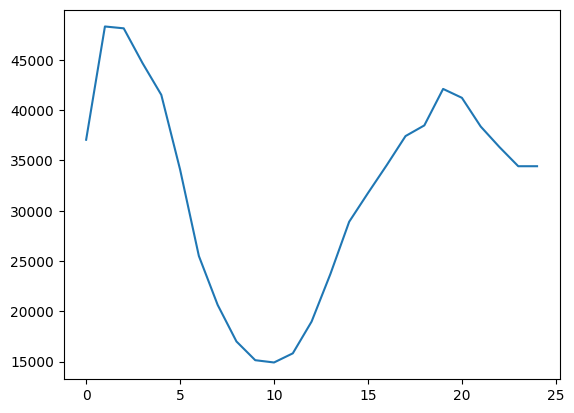

In [26]:
plt.plot(marginal_costs[0:25])